# Stage 5: XGBoost & Random Forest Training
## Hybrid Quantum-Classical NIDS - Classical Baselines

This notebook trains XGBoost and Random Forest models on VAE-reduced features (Stage 3 outputs) for UNSW-NB15 classification.

## 1. Setup & Imports

In [1]:
import os
import sys
import json
import warnings
import subprocess
import shutil
import zipfile
from datetime import datetime
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# ML Libraries
import xgboost as xgb
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import cross_val_score, cross_validate
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, classification_report, roc_auc_score,
    roc_curve, auc, balanced_accuracy_score
)
from sklearn.preprocessing import LabelEncoder
import joblib

warnings.filterwarnings('ignore')
%matplotlib inline
sns.set_style('whitegrid')

print("✅ All imports successful")
print(f"XGBoost version: {xgb.__version__}")

✅ All imports successful
XGBoost version: 3.2.0


## 2. Configure Kaggle Credentials & Download Datasets

In [2]:
# Install required packages
import os
import json
import sys
import subprocess

print("Installing required packages...")
subprocess.run([sys.executable, '-m', 'pip', 'install', '-q', 'kaggle', 'kagglehub'], capture_output=True)

# Kaggle API Credentials
KAGGLE_USERNAME_1 = "gandramonishreddy"
KAGGLE_KEY_1 = "86cb782ce481b01b5994fc903cd75f61"

KAGGLE_USERNAME_2 = "monadarling143"
KAGGLE_KEY_2 = "8579619194140e89af885820ef6bdb48"

# Setup Kaggle credentials
kaggle_dir = os.path.expanduser('~/.kaggle')
os.makedirs(kaggle_dir, exist_ok=True)
kaggle_json_path = os.path.join(kaggle_dir, 'kaggle.json')

# Configure with first dataset owner credentials (gandramonishreddy)
kaggle_creds = {
    "username": KAGGLE_USERNAME_1,
    "key": KAGGLE_KEY_1
}

with open(kaggle_json_path, 'w') as f:
    json.dump(kaggle_creds, f)

try:
    os.chmod(kaggle_json_path, 0o600)
except:
    pass

print(f"✅ Kaggle credentials configured")

Installing required packages...
✅ Kaggle credentials configured


## 3. Download Stage 3 Dataset (VAE Outputs)

In [3]:
# Download Stage 3 outputs
import os
import subprocess
import zipfile

stage3_dir = './stage3_vae_outputs'
os.makedirs(stage3_dir, exist_ok=True)

print("\n" + "="*60)
print("DOWNLOADING STAGE 3 VAE OUTPUTS")
print("="*60)

def has_parquet_files(path: str) -> bool:
    """Check if directory contains parquet files"""
    if not os.path.isdir(path):
        return False
    for file in os.listdir(path):
        if file.endswith('.parquet'):
            return True
    return False

if has_parquet_files(stage3_dir):
    print(f"✅ Stage 3 data already downloaded at: {stage3_dir}")
else:
    try:
        print("Downloading from Kaggle: gandramonishreddy/stage-3-vae-outputs")
        subprocess.run(
            ['kaggle', 'datasets', 'download',
             '-d', 'gandramonishreddy/stage-3-vae-outputs',
             '-p', stage3_dir,
             '--force'],
            check=True,
            text=True,
            encoding='utf-8',
            errors='ignore',
            capture_output=True
        )
        print("✅ Download complete")

        # Extract ZIP files
        for zip_file in os.listdir(stage3_dir):
            if zip_file.lower().endswith('.zip'):
                zip_path = os.path.join(stage3_dir, zip_file)
                print(f"Extracting {zip_file}...")
                with zipfile.ZipFile(zip_path, 'r') as zip_ref:
                    zip_ref.extractall(stage3_dir)
                os.remove(zip_path)
        print("✅ Stage 3 extraction complete")
    except Exception as e:
        print(f"❌ Error downloading Stage 3: {e}")
        raise


DOWNLOADING STAGE 3 VAE OUTPUTS
✅ Download complete
Extracting stage-3-vae-outputs.zip...
✅ Stage 3 extraction complete


## 4. Download Stage 2 Dataset (Optional)

In [4]:
# Download Stage 2 outputs (Optional - for comparison)
stage2_dir = './stage2_preprocessed'
os.makedirs(stage2_dir, exist_ok=True)

print("\n" + "="*60)
print("DOWNLOADING STAGE 2 PREPROCESSED DATA (OPTIONAL)")
print("="*60)

download_stage2 = False  # Set to True if you want to download Stage 2

if download_stage2:
    if has_parquet_files(stage2_dir):
        print(f"✅ Stage 2 data already downloaded at: {stage2_dir}")
    else:
        try:
            # Update credentials for Stage 2 dataset
            kaggle_creds_2 = {
                "username": KAGGLE_USERNAME_2,
                "key": KAGGLE_KEY_2
            }
            with open(kaggle_json_path, 'w') as f:
                json.dump(kaggle_creds_2, f)
            os.chmod(kaggle_json_path, 0o600)

            print("Downloading from Kaggle: monadarling143/stage-2-output-v2")
            subprocess.run(
                ['kaggle', 'datasets', 'download',
                 '-d', 'monadarling143/stage-2-output-v2',
                 '-p', stage2_dir,
                 '--force'],
                check=True,
                text=True,
                capture_output=True
            )
            print("✅ Download complete")

            # Extract ZIP files
            for zip_file in os.listdir(stage2_dir):
                if zip_file.lower().endswith('.zip'):
                    zip_path = os.path.join(stage2_dir, zip_file)
                    print(f"Extracting {zip_file}...")
                    with zipfile.ZipFile(zip_path, 'r') as zip_ref:
                        zip_ref.extractall(stage2_dir)
                    os.remove(zip_path)
            print("✅ Stage 2 extraction complete")
        except Exception as e:
            print(f"❌ Error downloading Stage 2: {e}")
else:
    print("Stage 2 download skipped (set download_stage2=True to enable)")


DOWNLOADING STAGE 2 PREPROCESSED DATA (OPTIONAL)
Stage 2 download skipped (set download_stage2=True to enable)


## 5. Load VAE-Reduced Data from Stage 3

In [5]:
# Configure paths
import os
from pathlib import Path
import pandas as pd

STAGE3_DIR = stage3_dir

# Find parquet files recursively (handles extracted nested folders)
parquet_paths = sorted(Path(STAGE3_DIR).rglob('*.parquet'))
parquet_files = [str(p) for p in parquet_paths]

print(f"Found parquet files in {STAGE3_DIR}:")
for p in parquet_paths:
    print(f"  - {p.name}")

if len(parquet_files) < 2:
    raise FileNotFoundError(
        f"Expected at least 2 parquet files (train/test), found {len(parquet_files)} in {STAGE3_DIR}. "
        "Re-run the Stage 3 download/extraction cell."
    )

# Load VAE latent representations
# Prefer explicit train/test names; otherwise fallback by file size.
train_candidates = [f for f in parquet_files if 'train' in Path(f).name.lower()]
test_candidates = [f for f in parquet_files if 'test' in Path(f).name.lower()]

if train_candidates and test_candidates:
    train_file = train_candidates[0]
    test_file = test_candidates[0]
else:
    if len(parquet_files) == 2:
        files_by_size = sorted(parquet_files, key=lambda f: os.path.getsize(f), reverse=True)
        train_file, test_file = files_by_size[0], files_by_size[1]
        print("⚠️ Train/Test names not found; using larger file as train and smaller as test.")
    else:
        raise ValueError(
            "Could not identify train/test parquet files by name. "
            "Ensure files contain 'train' and 'test' in names, or keep only 2 parquet files in the directory."
        )

print(f"Using train file: {Path(train_file).name}")
print(f"Using test file:  {Path(test_file).name}")

train_data = pd.read_parquet(train_file)
test_data = pd.read_parquet(test_file)

print("="*60)
print("DATASET SHAPES")
print("="*60)
print(f"Train Data: {train_data.shape}")
print(f"Test Data:  {test_data.shape}")
print(f"\nTrain Data Columns: {train_data.columns.tolist()}")
print(f"\nFirst 5 rows (Train):")
print(train_data.head())
print(f"\nData types:")
print(train_data.dtypes)

Found parquet files in ./stage3_vae_outputs:
  - vae_a_z_test.parquet
  - vae_a_z_train.parquet
  - vae_b_z_test.parquet
  - vae_b_z_train.parquet
Using train file: vae_a_z_train.parquet
Using test file:  vae_a_z_test.parquet
DATASET SHAPES
Train Data: (2381042, 8)
Test Data:  (573807, 8)

Train Data Columns: ['z_0', 'z_1', 'z_2', 'z_3', 'z_4', 'z_5', 'z_6', 'z_7']

First 5 rows (Train):
        z_0       z_1       z_2       z_3       z_4       z_5       z_6  \
0  1.434659  2.046466  2.195152  1.505254  2.406941  0.985846  1.332610   
1  1.662050  1.538786  2.218200  0.957752  2.080008  1.511902  2.266384   
2  0.738499  0.436296  0.786781  0.510592  0.913952  0.994762  1.184272   
3  1.653052  1.415384  1.934249  0.878087  2.137859  1.604605  2.123440   
4  2.960039  0.640096  1.355518  2.781394  0.582997  0.159580  1.727297   

        z_7  
0  0.472687  
1  0.364845  
2  0.542793  
3  0.383057  
4  1.121695  

Data types:
z_0    float32
z_1    float32
z_2    float32
z_3    float32
z

## 6. Separate Features & Labels

In [6]:
# Separate features and labels safely (Colab-friendly auto fallback)
import os
import json
import subprocess
import zipfile
from pathlib import Path
import pandas as pd

# Optional external label files (if known)
# Example:
# LABEL_TRAIN_PATH = '/content/labels_train.parquet'
# LABEL_TEST_PATH = '/content/labels_test.parquet'
LABEL_TRAIN_PATH = globals().get('LABEL_TRAIN_PATH', None)
LABEL_TEST_PATH = globals().get('LABEL_TEST_PATH', None)

# Reuse paths/credentials from earlier cells when available
STAGE3_DIR = globals().get('STAGE3_DIR', globals().get('stage3_dir', './stage3_vae_outputs'))
stage2_dir = globals().get('stage2_dir', './stage2_preprocessed')
kaggle_json_path = globals().get('kaggle_json_path', os.path.expanduser('~/.kaggle/kaggle.json'))
KAGGLE_USERNAME_2 = globals().get('KAGGLE_USERNAME_2', None)
KAGGLE_KEY_2 = globals().get('KAGGLE_KEY_2', None)

def read_table(path: str) -> pd.DataFrame:
    if path.lower().endswith('.parquet'):
        return pd.read_parquet(path)
    if path.lower().endswith('.csv'):
        return pd.read_csv(path)
    raise ValueError(f'Unsupported file format: {path}')

def extract_label_series(df: pd.DataFrame):
    # Prefer known label columns; fallback to None.
    label_cols = ['label', 'target', 'y', 'class', 'attack_cat', 'attack', 'is_attack']
    lower_to_real = {c.lower(): c for c in df.columns}
    for col in label_cols:
        if col in lower_to_real:
            return df[lower_to_real[col]]
    return None

def discover_label_files(base_dir: str, n_train: int, n_test: int):
    if not os.path.isdir(base_dir):
        return None, None

    files = [str(p) for p in Path(base_dir).rglob('*') if p.suffix.lower() in {'.parquet', '.csv'}]
    if not files:
        return None, None

    train_hit = None
    test_hit = None

    # First pass: prefer filename hints train/test and matching lengths.
    for path in files:
        name = Path(path).name.lower()
        try:
            df = read_table(path)
        except Exception:
            continue

        y = extract_label_series(df)
        if y is None:
            continue

        if ('train' in name) and (len(y) == n_train) and (train_hit is None):
            train_hit = (path, y)
        if ('test' in name) and (len(y) == n_test) and (test_hit is None):
            test_hit = (path, y)

    if train_hit and test_hit:
        return train_hit, test_hit

    # Second pass: match by length only.
    for path in files:
        try:
            df = read_table(path)
        except Exception:
            continue

        y = extract_label_series(df)
        if y is None:
            continue

        if (len(y) == n_train) and (train_hit is None):
            train_hit = (path, y)
        elif (len(y) == n_test) and (test_hit is None):
            test_hit = (path, y)

        if train_hit and test_hit:
            return train_hit, test_hit

    return train_hit, test_hit

def ensure_stage2_downloaded_for_labels():
    os.makedirs(stage2_dir, exist_ok=True)
    has_data = any(str(p).lower().endswith(('.parquet', '.csv')) for p in Path(stage2_dir).rglob('*'))
    if has_data:
        return

    if not (KAGGLE_USERNAME_2 and KAGGLE_KEY_2):
        return

    # Write credentials for stage2 owner if available.
    os.makedirs(os.path.dirname(kaggle_json_path), exist_ok=True)
    with open(kaggle_json_path, 'w') as f:
        json.dump({'username': KAGGLE_USERNAME_2, 'key': KAGGLE_KEY_2}, f)
    try:
        os.chmod(kaggle_json_path, 0o600)
    except Exception:
        pass

    try:
        subprocess.run(
            ['kaggle', 'datasets', 'download', '-d', 'monadarling143/stage-2-output-v2', '-p', stage2_dir, '--force'],
            check=True,
            text=True,
            encoding='utf-8',
            errors='ignore',
            capture_output=True
        )
        for zip_file in os.listdir(stage2_dir):
            if zip_file.lower().endswith('.zip'):
                zip_path = os.path.join(stage2_dir, zip_file)
                with zipfile.ZipFile(zip_path, 'r') as zip_ref:
                    zip_ref.extractall(stage2_dir)
                os.remove(zip_path)
        print('Auto-downloaded Stage 2 data for label recovery.')
    except Exception as e:
        print(f'Could not auto-download Stage 2 labels: {e}')

# 1) Try labels directly in Stage 3 train/test data
label_candidates = {'label', 'target', 'y', 'class', 'attack_cat', 'attack', 'is_attack'}
name_map = {c.lower(): c for c in train_data.columns}
found_labels = [name_map[c] for c in label_candidates if c in name_map]

if found_labels:
    label_col = found_labels[0]
    X_train = train_data.drop(columns=[label_col])
    y_train = train_data[label_col]
    X_test = test_data.drop(columns=[label_col])
    y_test = test_data[label_col]
else:
    X_train = train_data.copy()
    X_test = test_data.copy()
    y_train = None
    y_test = None
    label_col = 'external_label_file'

    # 2) If explicit external paths were provided, use them first.
    if LABEL_TRAIN_PATH and LABEL_TEST_PATH and os.path.exists(LABEL_TRAIN_PATH) and os.path.exists(LABEL_TEST_PATH):
        y_train_df = read_table(LABEL_TRAIN_PATH)
        y_test_df = read_table(LABEL_TEST_PATH)
        y_train = extract_label_series(y_train_df)
        y_test = extract_label_series(y_test_df)
        if y_train is None:
            y_train = y_train_df.iloc[:, 0]
        if y_test is None:
            y_test = y_test_df.iloc[:, 0]
        print(f'Using external label files: {LABEL_TRAIN_PATH} and {LABEL_TEST_PATH}')

    # 3) Auto-discover labels in Stage 3 tree.
    if y_train is None or y_test is None:
        train_hit, test_hit = discover_label_files(STAGE3_DIR, len(X_train), len(X_test))
        if train_hit and test_hit:
            train_label_path, y_train = train_hit
            test_label_path, y_test = test_hit
            print(f'Auto-discovered labels in Stage 3: {train_label_path} and {test_label_path}')

    # 4) Auto-discover labels in Stage 2 tree; auto-download Stage 2 if needed.
    if y_train is None or y_test is None:
        ensure_stage2_downloaded_for_labels()
        train_hit, test_hit = discover_label_files(stage2_dir, len(X_train), len(X_test))
        if train_hit and test_hit:
            train_label_path, y_train = train_hit
            test_label_path, y_test = test_hit
            print(f'Auto-discovered labels in Stage 2: {train_label_path} and {test_label_path}')

    if y_train is None or y_test is None:
        raise ValueError(
            'No label column found in Stage 3 parquet files and no matching external labels were discovered. '
            'For Colab, set LABEL_TRAIN_PATH and LABEL_TEST_PATH to .parquet/.csv label files, '
            'or run Stage 2 download with label-containing files.'
        )

# Final consistency check
if len(y_train) != len(X_train) or len(y_test) != len(X_test):
    raise ValueError(
        f'Label length mismatch. X_train={len(X_train)}, y_train={len(y_train)}, '
        f'X_test={len(X_test)}, y_test={len(y_test)}'
    )

print('='*60)
print('FEATURE & LABEL SEPARATION')
print('='*60)
print(f'Detected label source: {label_col}')
print(f'X_train shape: {X_train.shape}')
print(f'y_train shape: {y_train.shape}')
print(f'X_test shape:  {X_test.shape}')
print(f'y_test shape:  {y_test.shape}')
print(f'\nFeature columns: {X_train.columns.tolist()}')

# Print bounded class distribution to avoid notebook UI freeze
train_counts = pd.Series(y_train).value_counts(dropna=False)
test_counts = pd.Series(y_test).value_counts(dropna=False)
print(f'\nUnique classes in y_train: {train_counts.shape[0]}')
print(f'Unique classes in y_test:  {test_counts.shape[0]}')
print('\nTop 20 class counts (Train):')
print(train_counts.head(20))
print('\nTop 20 class counts (Test):')
print(test_counts.head(20))

Auto-downloaded Stage 2 data for label recovery.
Auto-discovered labels in Stage 2: stage2_preprocessed/STAGE_2_OUTPUT/stage_2_with_zero_v2/stage2_y_train.parquet and stage2_preprocessed/STAGE_2_OUTPUT/stage_2_with_zero_v2/stage2_y_test.parquet
FEATURE & LABEL SEPARATION
Detected label source: external_label_file
X_train shape: (2381042, 8)
y_train shape: (2381042,)
X_test shape:  (573807, 8)
y_test shape:  (573807,)

Feature columns: ['z_0', 'z_1', 'z_2', 'z_3', 'z_4', 'z_5', 'z_6', 'z_7']

Unique classes in y_train: 5
Unique classes in y_test:  5

Top 20 class counts (Train):
y
0    1813161
1     312881
2     150000
3      95000
4      10000
Name: count, dtype: int64

Top 20 class counts (Test):
y
0    453290
1     78221
2     29137
3     11966
4      1193
Name: count, dtype: int64


## 7. Data Validation & Check for Missing Values

In [7]:
print("="*60)
print("DATA VALIDATION")
print("="*60)

# Check for missing values
print(f"Missing values in X_train: {X_train.isnull().sum().sum()}")
print(f"Missing values in X_test:  {X_test.isnull().sum().sum()}")
print(f"Missing values in y_train: {y_train.isnull().sum()}")
print(f"Missing values in y_test:  {y_test.isnull().sum()}")

# Check data types
print(f"\nX_train dtypes:\n{X_train.dtypes}")

# Check for infinite values
print(f"\nInfinite values in X_train: {np.isinf(X_train.values).sum()}")
print(f"Infinite values in X_test:  {np.isinf(X_test.values).sum()}")

# Summary statistics
print(f"\nX_train statistics:")
print(X_train.describe())

DATA VALIDATION
Missing values in X_train: 0
Missing values in X_test:  0
Missing values in y_train: 0
Missing values in y_test:  0

X_train dtypes:
z_0    float32
z_1    float32
z_2    float32
z_3    float32
z_4    float32
z_5    float32
z_6    float32
z_7    float32
dtype: object

Infinite values in X_train: 0
Infinite values in X_test:  0

X_train statistics:
                z_0           z_1           z_2           z_3           z_4  \
count  2.381042e+06  2.381042e+06  2.381042e+06  2.381042e+06  2.381042e+06   
mean   1.546920e+00  1.459924e+00  1.844047e+00  1.350109e+00  1.860290e+00   
std    7.365957e-01  6.746534e-01  6.854995e-01  7.574989e-01  6.785023e-01   
min    1.569810e-08  5.772118e-18  3.880084e-10  7.416191e-16  7.383237e-05   
25%    1.033193e+00  1.067385e+00  1.441422e+00  8.563982e-01  1.374217e+00   
50%    1.649683e+00  1.492832e+00  2.020049e+00  1.080501e+00  1.988841e+00   
75%    1.963902e+00  1.855348e+00  2.287206e+00  1.755152e+00  2.257425e+00   
max

## 8. Encode Labels (if needed)

In [8]:
# Check if labels are numeric or string, with safeguards for high-cardinality targets
import numpy as np
import pandas as pd
from sklearn.preprocessing import LabelEncoder

n_unique = int(pd.Series(y_train).nunique(dropna=False))
print(f"Label dtype: {y_train.dtype}")
print(f"Unique label count: {n_unique}")

if n_unique > 1000:
    raise ValueError(
        "Label column has very high cardinality (>1000 unique values). "
        "This usually means a feature column was selected as label, which can freeze Colab output. "
        "Re-check the previous cell and provide a proper classification label column."
    )

if y_train.dtype == 'object' or str(y_train.dtype).startswith('category'):
    print("Labels are strings/categorical - encoding to numeric...")
    le = LabelEncoder()
    y_train = le.fit_transform(y_train)
    y_test = le.transform(y_test)
    label_mapping = dict(zip(le.classes_, le.transform(le.classes_)))
    print(f"Encoded classes: {len(label_mapping)}")
else:
    print("Labels are already numeric")
    unique_vals = np.sort(pd.Series(y_train).unique())
    if len(unique_vals) <= 100:
        label_mapping = {int(v) if float(v).is_integer() else float(v): int(v) if float(v).is_integer() else float(v) for v in unique_vals}
        print(f"Label mapping: {label_mapping}")
    else:
        label_mapping = {'info': f'{len(unique_vals)} numeric classes (mapping omitted for readability)'}
        print(label_mapping['info'])

# Print only a small sample to keep notebook responsive
train_unique_sample = pd.Series(y_train).drop_duplicates().head(20).tolist()
test_unique_sample = pd.Series(y_test).drop_duplicates().head(20).tolist()
print(f"\nSample labels in y_train (up to 20): {train_unique_sample}")
print(f"Sample labels in y_test  (up to 20): {test_unique_sample}")

Label dtype: int64
Unique label count: 5
Labels are already numeric
Label mapping: {0: 0, 1: 1, 2: 2, 3: 3, 4: 4}

Sample labels in y_train (up to 20): [0, 2, 1, 3, 4]
Sample labels in y_test  (up to 20): [0, 1, 3, 4, 2]


## 9. XGBoost Model Training

In [11]:
print("="*60)
print("XGBOOST MODEL TRAINING")
print("="*60)

# Number of classes
n_classes = len(np.unique(y_train))
objective = 'multi:softmax' if n_classes > 2 else 'binary:logistic'

# XGBoost parameters
xgb_params = {
    'max_depth': 7,
    'learning_rate': 0.1,
    'n_estimators': 200,
    'subsample': 0.8,
    'colsample_bytree': 0.8,
    'objective': objective,
    'num_class': n_classes,
    'random_state': 42,
    'n_jobs': -1,
    'eval_metric': 'mlogloss' if n_classes > 2 else 'logloss',
    'verbosity': 1
}

print(f"XGBoost Parameters:")
for key, val in xgb_params.items():
    print(f"  {key}: {val}")

# Train XGBoost
print(f"\nTraining XGBoost model...")
xgb_model = xgb.XGBClassifier(**xgb_params)
xgb_model.fit(
    X_train, y_train,
    eval_set=[(X_test, y_test)],
    verbose=False
)

print("✅ XGBoost training complete")

XGBOOST MODEL TRAINING
XGBoost Parameters:
  max_depth: 7
  learning_rate: 0.1
  n_estimators: 200
  subsample: 0.8
  colsample_bytree: 0.8
  objective: multi:softmax
  num_class: 5
  random_state: 42
  n_jobs: -1
  eval_metric: mlogloss
  verbosity: 1

Training XGBoost model...
✅ XGBoost training complete


## 10. XGBoost Evaluation

In [12]:
print("="*60)
print("XGBOOST EVALUATION")
print("="*60)

# Predictions
y_train_pred_xgb = xgb_model.predict(X_train)
y_test_pred_xgb = xgb_model.predict(X_test)

# Probability predictions (for multi-class)
y_test_proba_xgb = xgb_model.predict_proba(X_test)

# Training metrics
xgb_train_acc = accuracy_score(y_train, y_train_pred_xgb)
xgb_train_f1 = f1_score(y_train, y_train_pred_xgb, average='weighted')
xgb_train_balanced_acc = balanced_accuracy_score(y_train, y_train_pred_xgb)

print(f"\nTRAINING METRICS:")
print(f"  Accuracy:         {xgb_train_acc:.4f}")
print(f"  Balanced Accuracy: {xgb_train_balanced_acc:.4f}")
print(f"  Weighted F1:      {xgb_train_f1:.4f}")

# Test metrics
xgb_test_acc = accuracy_score(y_test, y_test_pred_xgb)
xgb_test_f1 = f1_score(y_test, y_test_pred_xgb, average='weighted')
xgb_test_balanced_acc = balanced_accuracy_score(y_test, y_test_pred_xgb)
xgb_test_precision = precision_score(y_test, y_test_pred_xgb, average='weighted')
xgb_test_recall = recall_score(y_test, y_test_pred_xgb, average='weighted')

print(f"\nTEST METRICS:")
print(f"  Accuracy:         {xgb_test_acc:.4f}")
print(f"  Balanced Accuracy: {xgb_test_balanced_acc:.4f}")
print(f"  Precision:        {xgb_test_precision:.4f}")
print(f"  Recall:           {xgb_test_recall:.4f}")
print(f"  Weighted F1:      {xgb_test_f1:.4f}")

# ROC-AUC for multi-class
try:
    xgb_test_roc_auc = roc_auc_score(y_test, y_test_proba_xgb, multi_class='ovr', average='weighted')
    print(f"  ROC-AUC (OvR):    {xgb_test_roc_auc:.4f}")
except:
    print(f"  ROC-AUC:          Not computed for this configuration")

print(f"\nCLASSIFICATION REPORT:\n")
print(classification_report(y_test, y_test_pred_xgb))

XGBOOST EVALUATION

TRAINING METRICS:
  Accuracy:         0.9753
  Balanced Accuracy: 0.8295
  Weighted F1:      0.9754

TEST METRICS:
  Accuracy:         0.9791
  Balanced Accuracy: 0.8249
  Precision:        0.9814
  Recall:           0.9791
  Weighted F1:      0.9796
  ROC-AUC (OvR):    0.9993

CLASSIFICATION REPORT:

              precision    recall  f1-score   support

           0       0.99      0.99      0.99    453290
           1       0.99      0.96      0.98     78221
           2       0.89      0.87      0.88     29137
           3       0.67      0.94      0.79     11966
           4       0.65      0.36      0.46      1193

    accuracy                           0.98    573807
   macro avg       0.84      0.82      0.82    573807
weighted avg       0.98      0.98      0.98    573807



## 11. Confusion Matrix Visualization

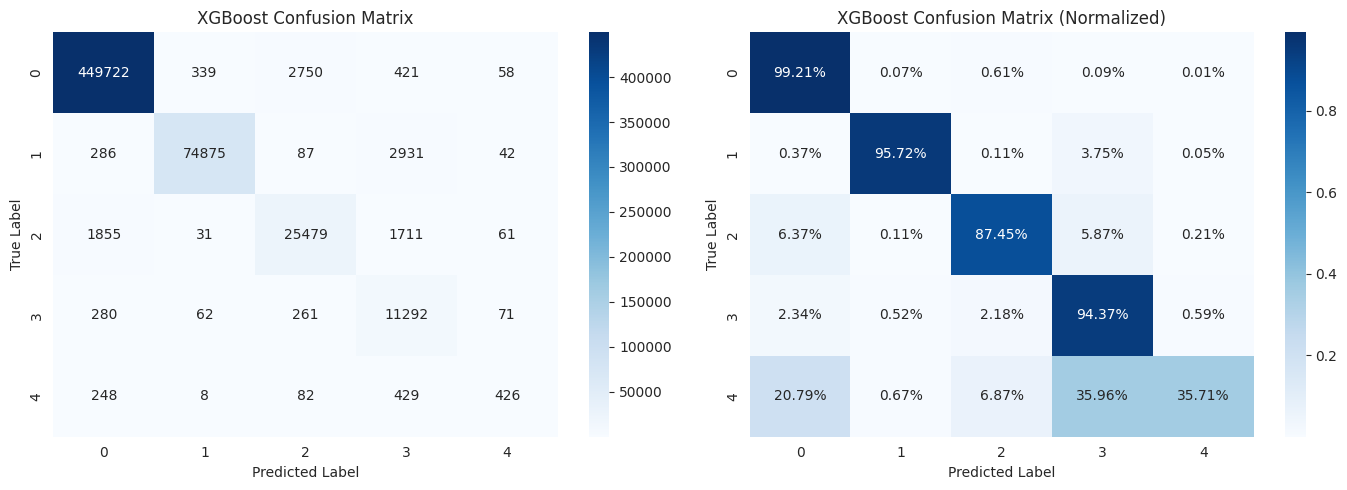

✅ Confusion matrix saved


In [13]:
# Confusion Matrix
cm_xgb = confusion_matrix(y_test, y_test_pred_xgb)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# XGBoost CM
sns.heatmap(cm_xgb, annot=True, fmt='d', cmap='Blues', ax=axes[0])
axes[0].set_title('XGBoost Confusion Matrix')
axes[0].set_ylabel('True Label')
axes[0].set_xlabel('Predicted Label')

# Normalized CM
cm_xgb_normalized = cm_xgb.astype('float') / cm_xgb.sum(axis=1)[:, np.newaxis]
sns.heatmap(cm_xgb_normalized, annot=True, fmt='.2%', cmap='Blues', ax=axes[1])
axes[1].set_title('XGBoost Confusion Matrix (Normalized)')
axes[1].set_ylabel('True Label')
axes[1].set_xlabel('Predicted Label')

plt.tight_layout()
plt.savefig('xgboost_confusion_matrix.png', dpi=300, bbox_inches='tight')
plt.show()

print("✅ Confusion matrix saved")

## 12. Feature Importance


Top 10 Important Features (XGBoost):
  Feature  Importance
7     z_7    0.461550
0     z_0    0.132152
3     z_3    0.112010
2     z_2    0.080163
5     z_5    0.075170
4     z_4    0.068238
1     z_1    0.043366
6     z_6    0.027351


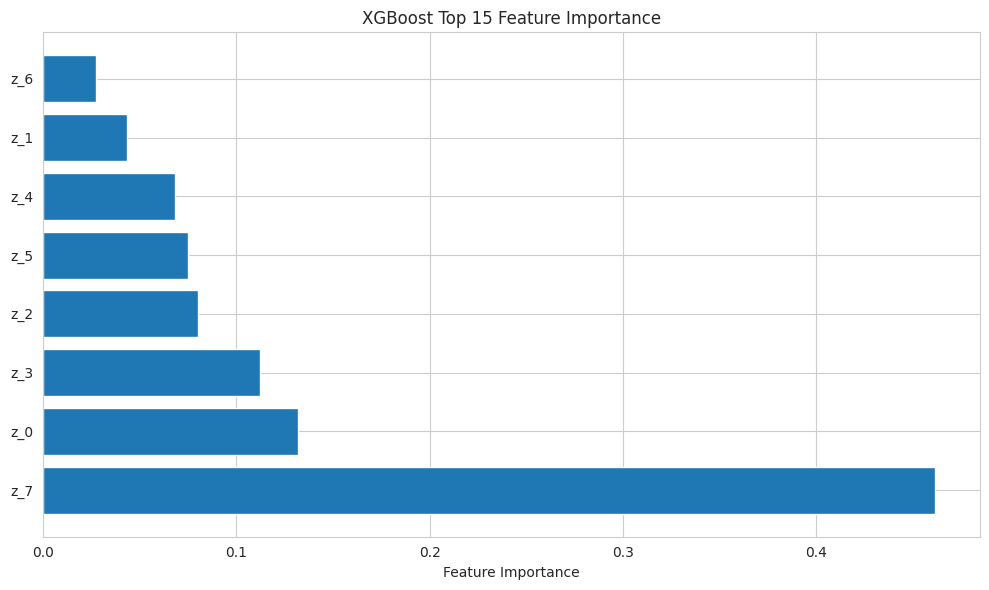

✅ Feature importance plot saved


In [14]:
# Get feature importance
feature_importance_xgb = xgb_model.feature_importances_
feature_names = X_train.columns.tolist()

# Create DataFrame for better visualization
importance_df = pd.DataFrame({
    'Feature': feature_names,
    'Importance': feature_importance_xgb
}).sort_values('Importance', ascending=False)

print("\nTop 10 Important Features (XGBoost):")
print(importance_df.head(10))

# Visualization
fig, ax = plt.subplots(figsize=(10, 6))
top_k = 15
ax.barh(importance_df['Feature'][:top_k], importance_df['Importance'][:top_k])
ax.set_xlabel('Feature Importance')
ax.set_title(f'XGBoost Top {top_k} Feature Importance')
plt.tight_layout()
plt.savefig('xgboost_feature_importance.png', dpi=300, bbox_inches='tight')
plt.show()

print("✅ Feature importance plot saved")

In [17]:
import joblib
import os
import zipfile
import shutil # Import shutil for moving files

# Define paths for saving the model and zip file
output_dir = './xgboost_output'
os.makedirs(output_dir, exist_ok=True)

xgb_model_filename = os.path.join(output_dir, 'xgboost_model.pkl')
zip_filename = 'xgboost_output.zip'

# Save the XGBoost model (re-saving to ensure it's in the correct output_dir)
joblib.dump(xgb_model, xgb_model_filename)
print(f"✅ XGBoost model saved to {xgb_model_filename}")

# Move plot files to the output directory if they exist in the current directory
plot_files_to_move = ['xgboost_confusion_matrix.png', 'xgboost_feature_importance.png']
for plot_file in plot_files_to_move:
    if os.path.exists(plot_file):
        destination_path = os.path.join(output_dir, plot_file)
        shutil.move(plot_file, destination_path)
        print(f"Moved {plot_file} to {output_dir}")
    else:
        print(f"Warning: Plot file not found in current directory: {plot_file}")

# List of files to include in the zip archive (all now expected in output_dir)
files_to_zip = [
    xgb_model_filename,
    os.path.join(output_dir, 'xgboost_confusion_matrix.png'),
    os.path.join(output_dir, 'xgboost_feature_importance.png')
]

# Create the zip file
with zipfile.ZipFile(zip_filename, 'w') as zf:
    for file_path in files_to_zip:
        if os.path.exists(file_path):
            # Add file to zip with its base name
            zf.write(file_path, os.path.basename(file_path))
            print(f"Added {file_path} to {zip_filename}")
        else:
            print(f"Warning: File not found and skipped: {file_path}")

print(f"\n✅ All selected outputs zipped into {zip_filename}")
print(f"You can download '{zip_filename}' from the Colab file browser.")

✅ XGBoost model saved to ./xgboost_output/xgboost_model.pkl
Added ./xgboost_output/xgboost_model.pkl to xgboost_output.zip
Added ./xgboost_output/xgboost_confusion_matrix.png to xgboost_output.zip
Added ./xgboost_output/xgboost_feature_importance.png to xgboost_output.zip

✅ All selected outputs zipped into xgboost_output.zip
You can download 'xgboost_output.zip' from the Colab file browser.
